# Modelo 2.2 - Comparador unificado de arquitecturas

Este cuaderno presenta un **pipeline unico y reproducible** para comparar arquitecturas de deteccion de spoofing de voz.

Arquitecturas incluidas en la comparativa final:
1. `A_spatial_cnn` (CNN 2D con mezcla local tiempo-frecuencia).
2. `B_freq_only_cnn` (CNN 2D con convolucion solo frecuencial).
3. `C_independent_frames` (encoder por frame + agregacion global).

Decisiones metodologicas clave de este refactor:
- Se elimina la duplicidad entre el modelo base inicial y la opcion A, manteniendo una sola implementacion representativa.
- Todos los modelos se entrenan en `train` con el mismo protocolo para asegurar comparabilidad justa.
- El umbral de decision se selecciona en `dev` para cada modelo (sin usar `eval` para calibrar).
- La evaluacion final se reporta en `dev` y `eval` para medir rendimiento in-domain y robustez cross-domain.

La narrativa y los comentarios se orientan a defensa academica: cada bloque explica que se hace, por que se hace y como interpretar los resultados.

In [1]:
# ==============================
# 1) Imports, semillas y utilidades globales
# ==============================
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_curve,
    precision_recall_curve,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


def ensure_4d(x):
    """Normaliza entradas a formato (N, T, F, C) para Conv2D."""
    x = np.asarray(x)
    if x.ndim == 4:
        return x
    if x.ndim == 3:
        return np.expand_dims(x, axis=-1)
    if x.ndim == 5 and x.shape[-1] == 1:
        return np.squeeze(x, axis=-1)
    raise ValueError(f'Shape no soportado para Conv2D: {x.shape}')


def compile_binary_model(model, lr=1e-3):
    """Compilacion comun para garantizar una comparativa justa entre arquitecturas."""
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model


def robust_predict_proba(model, x):
    """Prediccion robusta ante fallo intermitente de Keras 3 en model.predict."""
    try:
        return model.predict(x, batch_size=64, verbose=0).ravel()
    except UnboundLocalError as e:
        if 'batch_outputs' not in str(e):
            raise
        return model(x, training=False).numpy().ravel()


def select_best_threshold_f1(y_true, y_prob):
    """
    Selecciona umbral en DEV maximizando F1 de la clase spoof.
    Se usa DEV para calibrar decision y EVAL queda reservado para validacion final.
    """
    thresholds = np.linspace(0.05, 0.95, 181)
    best_thr = 0.5
    best_f1 = -1.0
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='binary', pos_label=1, zero_division=0
        )
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)
    return best_thr, best_f1


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1, zero_division=0
    )
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    ll = log_loss(y_true, np.clip(y_prob, 1e-7, 1 - 1e-7))
    brier = brier_score_loss(y_true, y_prob)
    mcc = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        'threshold': float(threshold),
        'accuracy': acc,
        'balanced_accuracy': bacc,
        'precision_spoof': precision,
        'recall_spoof': recall,
        'f1_spoof': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'log_loss': ll,
        'brier': brier,
        'mcc': mcc,
        'kappa': kappa,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'tpr': tpr,
        'tnr': tnr,
        'fpr': fpr,
        'fnr': fnr,
    }

In [2]:
# ==============================
# 2) Carga de datos (train/dev/eval)
# ==============================
# Nota metodologica: el split se genera en ETL externo y aqui se consume sin alterarlo,
# para preservar trazabilidad y evitar leakage entre entrenamiento y evaluacion.
RUTA_TRAIN = '../Metricas/ETL_V2.1_train/'
RUTA_DEV = '../Metricas/ETL_V2.1_dev/'
RUTA_EVAL = '../Metricas/ETL_V2.1_eval/'

X_train_raw = np.load(f'{RUTA_TRAIN}X_fourier_features.npy')
y_train = np.load(f'{RUTA_TRAIN}y_labels.npy').astype('int32')

X_dev_raw = np.load(f'{RUTA_DEV}X_fourier_features.npy')
y_dev = np.load(f'{RUTA_DEV}y_labels.npy').astype('int32')

X_eval_raw = np.load(f'{RUTA_EVAL}X_fourier_features.npy')
y_eval = np.load(f'{RUTA_EVAL}y_labels.npy').astype('int32')

X_train_cnn = ensure_4d(X_train_raw).astype('float32')
X_dev_cnn = ensure_4d(X_dev_raw).astype('float32')
X_eval_cnn = ensure_4d(X_eval_raw).astype('float32')

print('Shapes cargados:')
print(' - TRAIN:', X_train_cnn.shape, y_train.shape)
print(' - DEV  :', X_dev_cnn.shape, y_dev.shape)
print(' - EVAL :', X_eval_cnn.shape, y_eval.shape)

print('\nDistribucion de clases (0=bonafide, 1=spoof):')
for split_name, y_split in [('TRAIN', y_train), ('DEV', y_dev), ('EVAL', y_eval)]:
    values, counts = np.unique(y_split, return_counts=True)
    dist = {int(v): int(c) for v, c in zip(values, counts)}
    print(f' - {split_name}: {dist}')

if X_eval_cnn.shape[0] == 0:
    raise ValueError('El conjunto EVAL esta vacio. Revisar exportacion del ETL.')

Shapes cargados:
 - TRAIN: (25380, 5, 1025, 1) (25380,)
 - DEV  : (24844, 5, 1025, 1) (24844,)
 - EVAL : (71237, 5, 1025, 1) (71237,)

Distribucion de clases (0=bonafide, 1=spoof):
 - TRAIN: {0: 2580, 1: 22800}
 - DEV: {0: 2548, 1: 22296}
 - EVAL: {0: 7355, 1: 63882}


## Justificacion de diseno del comparador

La comparativa se centra en tres hipotesis arquitecturales complementarias y no redundantes:

- **A_spatial_cnn**: asume que existe correlacion local entre tiempo y frecuencia, por eso usa kernels 2D `3x3` y `pooling (1, 8)` para preservar el eje temporal corto (5 frames) y comprimir frecuencia.
- **B_freq_only_cnn**: restringe la convolucion al eje frecuencial con kernels `(1, k)` para aislar el efecto de no mezclar temporalmente en la extraccion local.
- **C_independent_frames**: procesa cada frame por separado y agrega globalmente; esta hipotesis es consistente con una ETL donde las 5 muestras son equidistantes y no necesariamente contiguas.

Decision de refactor relevante: el modelo base inicial se elimina porque es funcionalmente equivalente a la opcion A, y mantener ambos inflaba el benchmark sin aportar una hipotesis nueva.

Con esta simplificacion se conserva el analisis exhaustivo, pero se mejora la claridad metodologica de cara a la memoria universitaria.

## Fabrica unica de modelos comparables

A partir de este punto el notebook utiliza una sola fabrica de arquitecturas y un solo bucle de entrenamiento.

Criterio de comparacion justa:
- mismo dataset de entrenamiento (`train`),
- misma validacion (`dev`),
- mismo optimizador y criterio de parada,
- mismas metricas de evaluacion,
- y calibracion de umbral en `dev` antes de evaluar en `eval`.

In [4]:
# ==============================
# 3) Definicion unificada de arquitecturas
# ==============================
def build_option_a_spatial_cnn(input_shape):
    """Opcion A: CNN 2D con mezcla local tiempo-frecuencia."""
    model = models.Sequential(name='A_spatial_cnn')
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((1, 8), padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((1, 8), padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))
    return compile_binary_model(model)


def build_option_b_freq_only_cnn(input_shape):
    """Opcion B: convolucion solo en frecuencia para aislar sesgo temporal."""
    model = models.Sequential(name='B_freq_only_cnn')
    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (1, 9), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((1, 4), padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.Conv2D(64, (1, 9), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((1, 4), padding='same'))
    model.add(layers.BatchNormalization())

    model.add(layers.Conv2D(128, (1, 5), padding='same', activation='relu'))
    model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(1, activation='sigmoid'))
    return compile_binary_model(model)


def build_option_c_independent_frames(input_shape):
    """Opcion C: encoder por frame y agregacion global sin vecindad temporal local."""
    inp = layers.Input(shape=input_shape, name='input_4d')

    x = layers.TimeDistributed(layers.Conv1D(32, 9, padding='same', activation='relu'))(inp)
    x = layers.TimeDistributed(layers.MaxPooling1D(4))(x)

    x = layers.TimeDistributed(layers.Conv1D(64, 9, padding='same', activation='relu'))(x)
    x = layers.TimeDistributed(layers.MaxPooling1D(4))(x)

    x = layers.TimeDistributed(layers.Conv1D(128, 5, padding='same', activation='relu'))(x)
    x = layers.TimeDistributed(layers.GlobalMaxPooling1D())(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=inp, outputs=out, name='C_independent_frames')
    return compile_binary_model(model)


def get_model_builders():
    """Fabrica unica para el comparador."""
    return {
        'A_spatial_cnn': build_option_a_spatial_cnn,
        'B_freq_only_cnn': build_option_b_freq_only_cnn,
        'C_independent_frames': build_option_c_independent_frames,
    }

In [5]:
# ==============================
# 4) Entrenamiento homogeneo de modelos en TRAIN
# ==============================
input_shape = X_train_cnn.shape[1:]
builders = get_model_builders()

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

models_dict = {}
histories = {}
train_times = {}

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=6,
        restore_best_weights=True,
        verbose=1,
    )
]

EPOCHS = 40
BATCH_SIZE = 32

print('Entrenamiento con TRAIN y validacion en DEV')
print('class_weight:', class_weight)

for name, builder in builders.items():
    print('\n' + '=' * 70)
    print(f'Entrenando modelo: {name}')
    print('=' * 70)

    model = builder(input_shape)
    t0 = time.time()

    history = model.fit(
        X_train_cnn,
        y_train,
        validation_data=(X_dev_cnn, y_dev),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1,
    )

    elapsed = time.time() - t0
    models_dict[name] = model
    histories[name] = history.history
    train_times[name] = elapsed

    print(f'Tiempo de entrenamiento ({name}): {elapsed/60:.2f} minutos')

Entrenamiento con TRAIN y validacion en DEV
class_weight: {0: 4.9186046511627906, 1: 0.5565789473684211}

Entrenando modelo: A_spatial_cnn
Epoch 1/40
794/794 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.4885 - auc: 0.6622 - loss: 0.6488 - val_accuracy: 0.6400 - val_auc: 0.7577 - val_loss: 0.5031
Epoch 2/40
794/794 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.4190 - auc: 0.7101 - loss: 0.5820 - val_accuracy: 0.6611 - val_auc: 0.7206 - val_loss: 0.4608
Epoch 3/40
794/794 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.4481 - auc: 0.7214 - loss: 0.5699 - val_accuracy: 0.6592 - val_auc: 0.7692 - val_loss: 0.4760
Epoch 4/40
794/794 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.5094 - auc: 0.7551 - loss: 0.5489 - val_accuracy: 0.7759 - val_auc: 0.8297 - val_loss: 0.4680
Epoch 5/40
794/794 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.6138 - auc: 0.8080 - loss: 0.5095 - val_accuracy: 0.8118 - val_auc: 0.8333 - val_loss: 0.3987
Epoch 6/40
794/794 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/st

## Evaluacion integral con calibracion en DEV

Primero se calibra el umbral de decision por modelo en `dev` maximizando F1 de la clase spoof.

Justificacion academica:
- `dev` se usa para ajustar decision operativa (umbral),
- `eval` se reserva para medir generalizacion real,
- esta separacion evita contaminar la evaluacion cross-domain.

Justificacion desde perspectiva de negocio:
- En un escenario antifraude por voz, la clase `spoof` representa el riesgo economico principal (suplantacion, fraude transaccional y coste reputacional).
- Maximizar F1 de `spoof` equilibra dos objetivos operativos criticos: **no dejar pasar ataques** (alto recall) y **no bloquear en exceso casos legitimos** (precision razonable).
- Si se optimizara solo accuracy, el desbalance de clases podria ocultar un mal desempeno sobre el fraude real; F1 en `spoof` enfoca la optimizacion donde el impacto de negocio es mayor.

Se reportan metricas robustas para desbalance (`balanced_accuracy`, `PR-AUC`, `MCC`), discriminacion (`ROC-AUC`), error probabilistico (`log_loss`, `brier`) y comportamiento de confusion (`FP/FN/TP/TN`).

=== Ranking DEV (ordenado por ROC-AUC) ===


,threshold,accuracy,balanced_accuracy,precision_spoof,recall_spoof,f1_spoof,roc_auc,pr_auc,mcc,kappa,log_loss,brier,train_time_sec
model,,,,,,,,,,,,,
C_independent_frames,0.075,0.9881,0.9638,0.9924,0.9944,0.9934,0.9979,0.9998,0.9350,0.9350,0.0546,0.0159,1025.2104
A_spatial_cnn,0.135,0.9625,0.8846,0.9758,0.9826,0.9792,0.9828,0.9978,0.7912,0.7907,0.1582,0.0484,427.3032
B_freq_only_cnn,0.050,0.8974,0.5000,0.8974,1.0000,0.9459,0.6823,0.9521,0.0000,0.0000,0.6397,0.2310,154.5396



=== Conteos de matriz de confusion en DEV ===


,tn,fp,fn,tp,tpr,tnr,fpr,fnr
model,,,,,,,,
C_independent_frames,2378,170,125,22171,0.9944,0.9333,0.0667,0.0056
A_spatial_cnn,2004,544,387,21909,0.9826,0.7865,0.2135,0.0174
B_freq_only_cnn,0,2548,0,22296,1.0000,0.0000,1.0000,0.0000



=== Umbral seleccionado por modelo (optimiza F1 en DEV) ===


,threshold_dev
B_freq_only_cnn,0.050
C_independent_frames,0.075
A_spatial_cnn,0.135


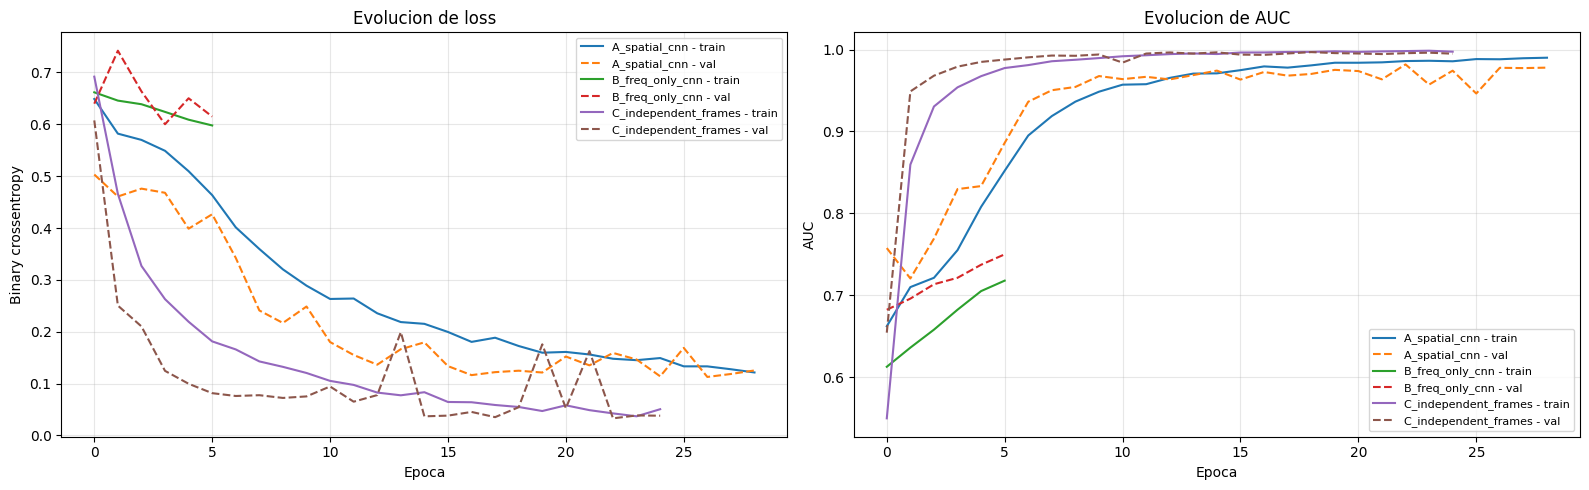

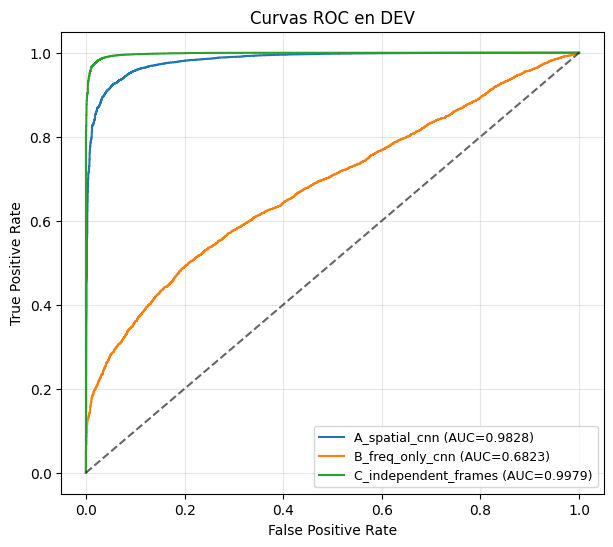

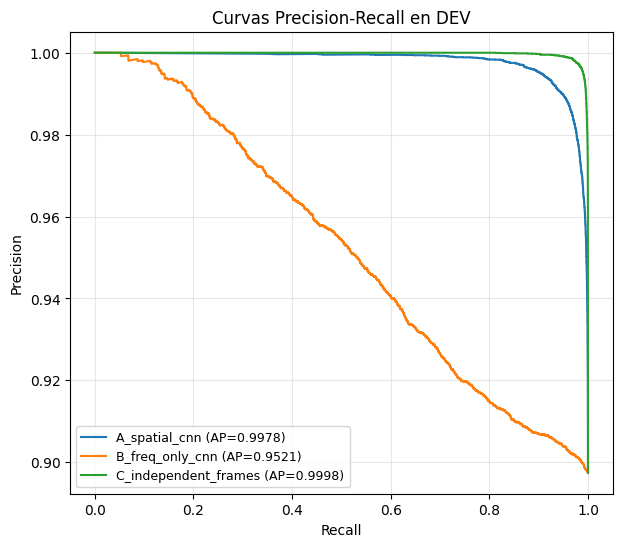

C:\Users\Lechu\AppData\Local\Temp\ipykernel_25420\1460145497.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


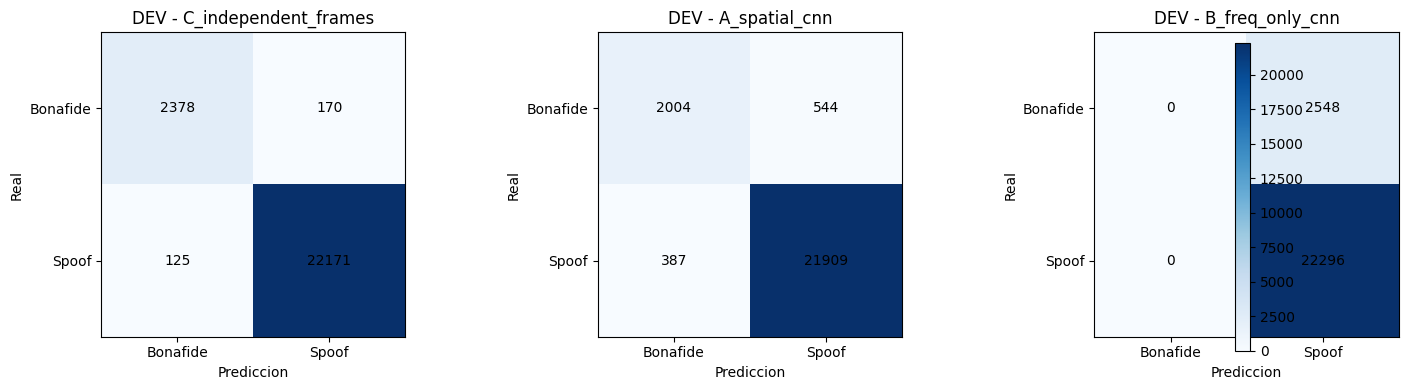

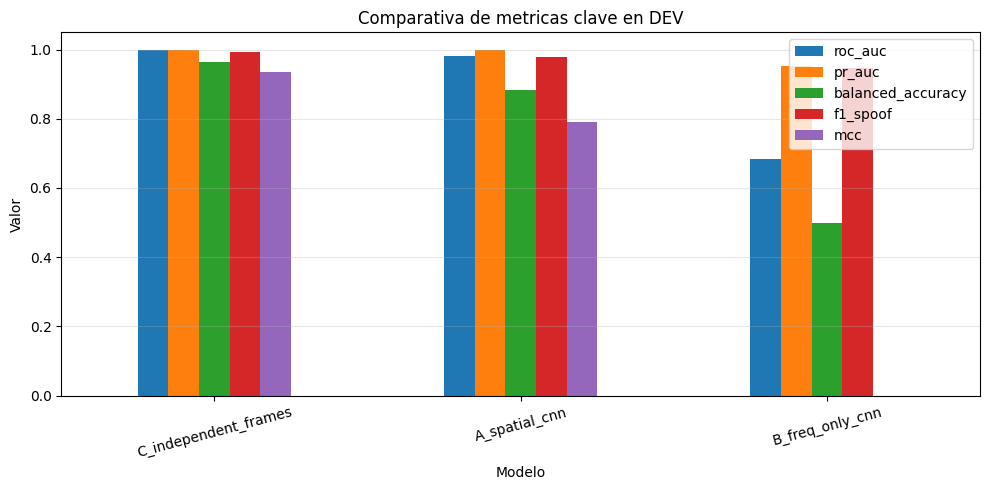

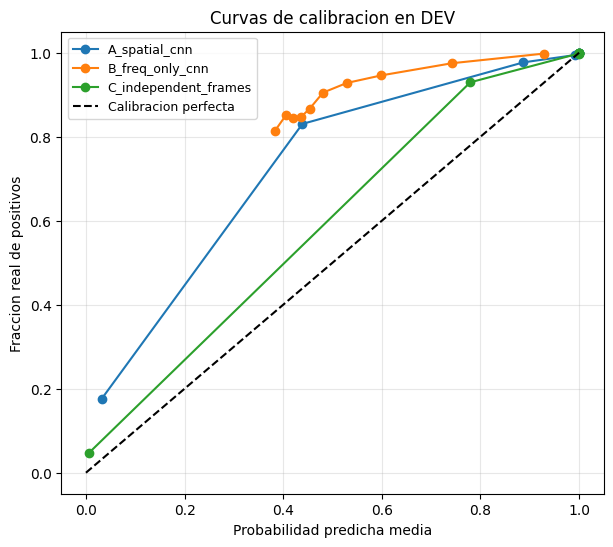

In [6]:
# ==============================
# 5) Evaluacion exhaustiva en DEV y calibracion de umbral
# ==============================
all_metrics_dev = []
prob_by_model_dev = {}
cm_by_model_dev = {}
roc_data_dev = {}
pr_data_dev = {}
thresholds_by_model = {}

for name, model in models_dict.items():
    y_prob_dev = robust_predict_proba(model, X_dev_cnn)
    best_thr, best_f1_dev = select_best_threshold_f1(y_dev, y_prob_dev)

    thresholds_by_model[name] = best_thr
    prob_by_model_dev[name] = y_prob_dev

    metrics_dict = compute_metrics(y_dev, y_prob_dev, threshold=best_thr)
    metrics_dict['model'] = name
    metrics_dict['train_time_sec'] = train_times[name]
    metrics_dict['dev_f1_at_selected_threshold'] = best_f1_dev

    all_metrics_dev.append(metrics_dict)

    y_pred_dev = (y_prob_dev >= best_thr).astype(int)
    cm_by_model_dev[name] = confusion_matrix(y_dev, y_pred_dev)

    fpr, tpr, _ = roc_curve(y_dev, y_prob_dev)
    roc_data_dev[name] = (fpr, tpr)

    p, r, _ = precision_recall_curve(y_dev, y_prob_dev)
    pr_data_dev[name] = (r, p)

results_dev_df = pd.DataFrame(all_metrics_dev).set_index('model').sort_values('roc_auc', ascending=False)

cols_main = [
    'threshold', 'accuracy', 'balanced_accuracy', 'precision_spoof', 'recall_spoof',
    'f1_spoof', 'roc_auc', 'pr_auc', 'mcc', 'kappa', 'log_loss', 'brier', 'train_time_sec'
]

print('=== Ranking DEV (ordenado por ROC-AUC) ===')
display(results_dev_df[cols_main].round(4))

print('\n=== Conteos de matriz de confusion en DEV ===')
display(results_dev_df[['tn', 'fp', 'fn', 'tp', 'tpr', 'tnr', 'fpr', 'fnr']].round(4))

print('\n=== Umbral seleccionado por modelo (optimiza F1 en DEV) ===')
display(pd.Series(thresholds_by_model, name='threshold_dev').sort_values().to_frame().round(4))

# ==============================
# 6) Graficos comparativos en DEV
# ==============================
plt.style.use('default')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for name, hist in histories.items():
    axes[0].plot(hist['loss'], label=f'{name} - train')
    axes[0].plot(hist['val_loss'], linestyle='--', label=f'{name} - val')
axes[0].set_title('Evolucion de loss')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Binary crossentropy')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

for name, hist in histories.items():
    axes[1].plot(hist['auc'], label=f'{name} - train')
    axes[1].plot(hist['val_auc'], linestyle='--', label=f'{name} - val')
axes[1].set_title('Evolucion de AUC')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('AUC')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
for name, (fpr, tpr) in roc_data_dev.items():
    auc_val = results_dev_df.loc[name, 'roc_auc']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.title('Curvas ROC en DEV')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()

plt.figure(figsize=(7, 6))
for name, (rec, prec) in pr_data_dev.items():
    ap = results_dev_df.loc[name, 'pr_auc']
    plt.plot(rec, prec, label=f'{name} (AP={ap:.4f})')
plt.title('Curvas Precision-Recall en DEV')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()

model_names = list(results_dev_df.index)
fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4))
if len(model_names) == 1:
    axes = [axes]
for ax, name in zip(axes, model_names):
    cm = cm_by_model_dev[name]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'DEV - {name}')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Bonafide', 'Spoof'])
    ax.set_yticklabels(['Bonafide', 'Spoof'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center')
fig.colorbar(im, ax=axes, fraction=0.025)
plt.tight_layout()
plt.show()

metrics_to_plot = ['roc_auc', 'pr_auc', 'balanced_accuracy', 'f1_spoof', 'mcc']
plot_df = results_dev_df[metrics_to_plot].copy()
ax = plot_df.plot(kind='bar', figsize=(10, 5))
ax.set_title('Comparativa de metricas clave en DEV')
ax.set_ylabel('Valor')
ax.set_xlabel('Modelo')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
for name, y_prob in prob_by_model_dev.items():
    frac_pos, mean_pred = calibration_curve(y_dev, y_prob, n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', label=name)
plt.plot([0, 1], [0, 1], 'k--', label='Calibracion perfecta')
plt.title('Curvas de calibracion en DEV')
plt.xlabel('Probabilidad predicha media')
plt.ylabel('Fraccion real de positivos')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()

## Guia de analisis academico de resultados

Este bloque esta pensado para redactar la memoria a partir de tablas y graficos generados automaticamente.

### 1) Lectura recomendada en DEV (in-domain)

1. Revisar primero `roc_auc`, `pr_auc` y `balanced_accuracy` para comparar capacidad de discriminacion global.
2. Revisar despues `f1_spoof`, `recall_spoof` y `mcc` para analizar comportamiento operativo en deteccion de fraude.
3. Contrastar `log_loss` y `brier` para valorar calibracion probabilistica.
4. Interpretar matrices de confusion para explicar el coste relativo de `FP` y `FN` en el caso de uso.

### 2) Justificacion del umbral por modelo

El umbral no se fija en 0.5 de forma arbitraria: se optimiza en `dev` para maximizar F1 de spoof.

Esta eleccion se justifica porque:
- el problema esta desbalanceado,
- el objetivo aplicado prioriza detectar spoof sin ignorar precision,
- y permite una comparativa mas justa entre arquitecturas con distintas distribuciones de probabilidad.

### 3) Lectura recomendada en EVAL (cross-domain)

La comparacion `DEV -> EVAL` permite medir robustez fuera de dominio.

Puntos a reportar en la memoria:
- degradacion relativa por metrica (`delta`),
- estabilidad del ranking de modelos entre dominios,
- y evidencia de sobreajuste a dominio cuando la caida es abrupta.

### 4) Amenazas a la validez y alcance de las conclusiones

- Si `dev` y `train` comparten condiciones de captura similares, las metricas in-domain pueden sobreestimar rendimiento real.
- `eval` debe interpretarse como aproximacion a escenario real de atacantes no vistos.
- Una conclusion fuerte debe priorizar consistencia en `eval`, no solo maxima puntuacion en `dev`.


## Evaluacion de robustez cross-domain en `eval`

En esta fase no se reentrena ni recalibra ningun modelo.

Principio metodologico aplicado:
- el umbral se fija usando solo `dev`,
- ese umbral se traslada a `eval`,
- y en `eval` solo se mide capacidad de generalizacion ante atacantes no vistos.

Este protocolo evita leakage experimental y fortalece la validez de la comparativa en un contexto universitario.

Shapes en EVAL:
X_eval_cnn: (71237, 5, 1025, 1) | y_eval: (71237,)
=== Resultados en EVAL (cross-domain) ===


,threshold,accuracy,balanced_accuracy,precision_spoof,recall_spoof,f1_spoof,roc_auc,pr_auc,mcc,kappa,log_loss,brier
model,,,,,,,,,,,,
A_spatial_cnn,0.135,0.8948,0.8485,0.9740,0.9069,0.9393,0.9435,0.9934,0.5713,0.5510,0.4824,0.1108
C_independent_frames,0.075,0.7982,0.8627,0.9918,0.7815,0.8742,0.9262,0.9912,0.4848,0.3997,1.3101,0.2533
B_freq_only_cnn,0.050,0.8968,0.5000,0.8968,1.0000,0.9456,0.8588,0.9819,0.0000,0.0000,0.4559,0.1517



=== Comparacion DEV vs EVAL (delta = eval - dev) ===


,threshold_dev,accuracy_dev,balanced_accuracy_dev,precision_spoof_dev,recall_spoof_dev,f1_spoof_dev,roc_auc_dev,pr_auc_dev,mcc_dev,kappa_dev,...,delta_balanced_accuracy,delta_precision_spoof,delta_recall_spoof,delta_f1_spoof,delta_roc_auc,delta_pr_auc,delta_mcc,delta_kappa,delta_log_loss,delta_brier
model,,,,,,,,,,,,,,,,,,,,,
C_independent_frames,0.075,0.9881,0.9638,0.9924,0.9944,0.9934,0.9979,0.9998,0.9350,0.9350,...,-0.1011,-0.0006,-0.2129,-0.1192,-0.0717,-0.0086,-0.4503,-0.5353,1.2556,0.2374
A_spatial_cnn,0.135,0.9625,0.8846,0.9758,0.9826,0.9792,0.9828,0.9978,0.7912,0.7907,...,-0.0361,-0.0017,-0.0758,-0.0399,-0.0393,-0.0045,-0.2200,-0.2397,0.3242,0.0624
B_freq_only_cnn,0.050,0.8974,0.5000,0.8974,1.0000,0.9459,0.6823,0.9521,0.0000,0.0000,...,0.0000,-0.0007,0.0000,-0.0004,0.1765,0.0298,0.0000,0.0000,-0.1838,-0.0793


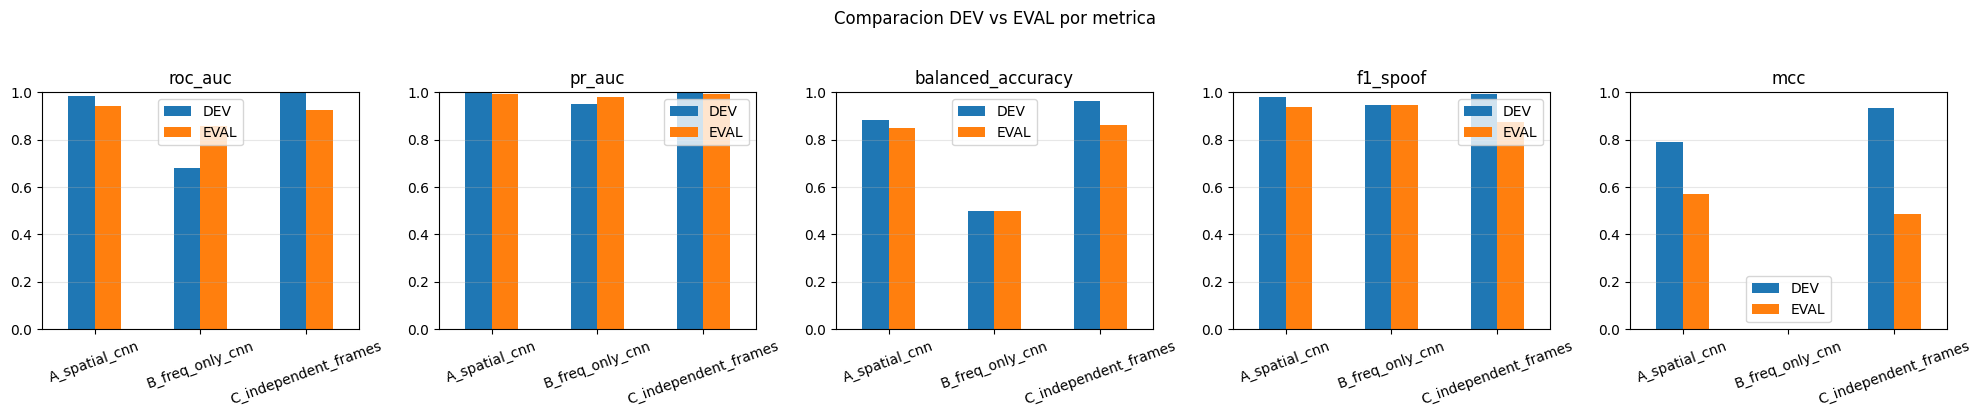

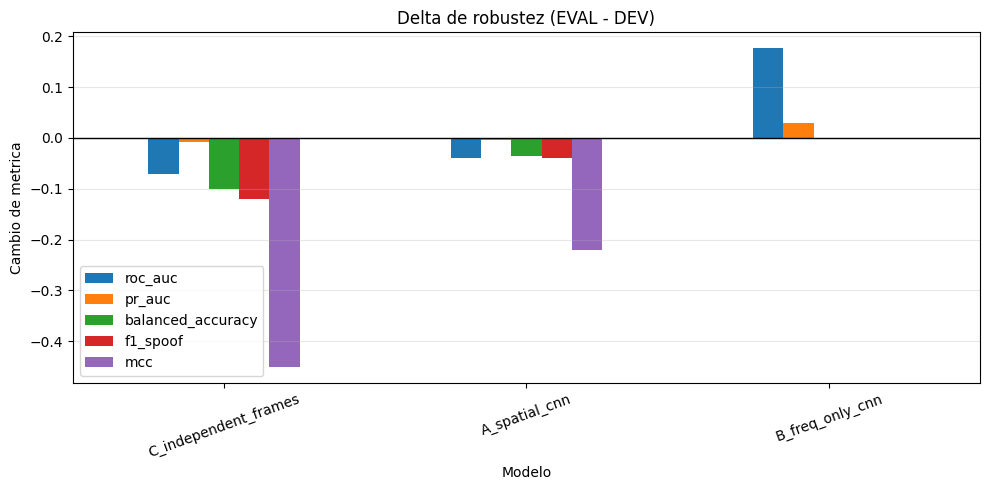

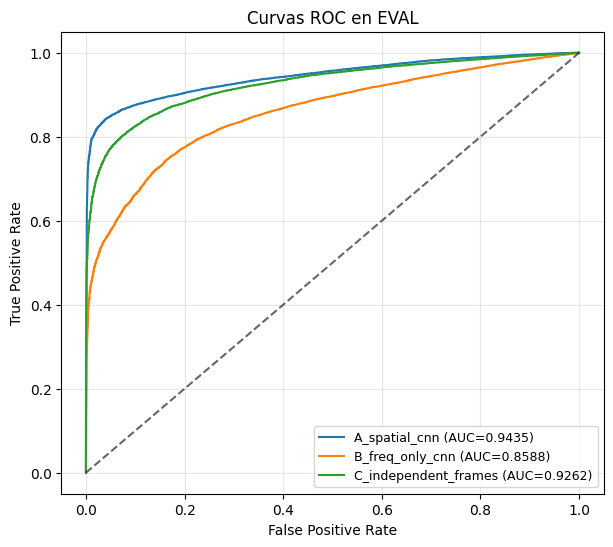

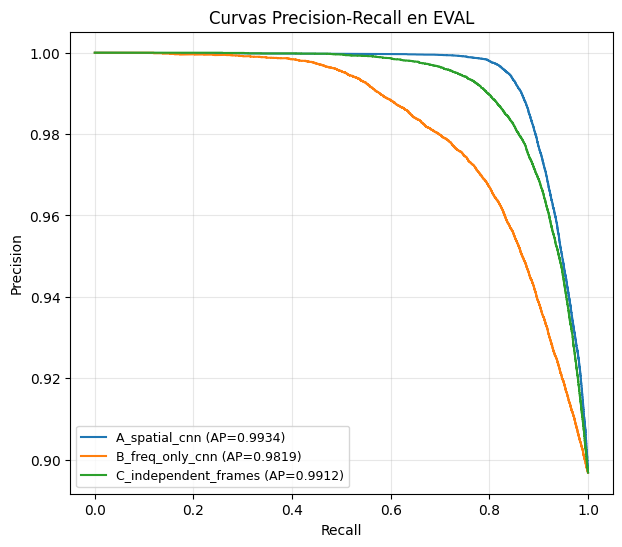

C:\Users\Lechu\AppData\Local\Temp\ipykernel_25420\3025534555.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


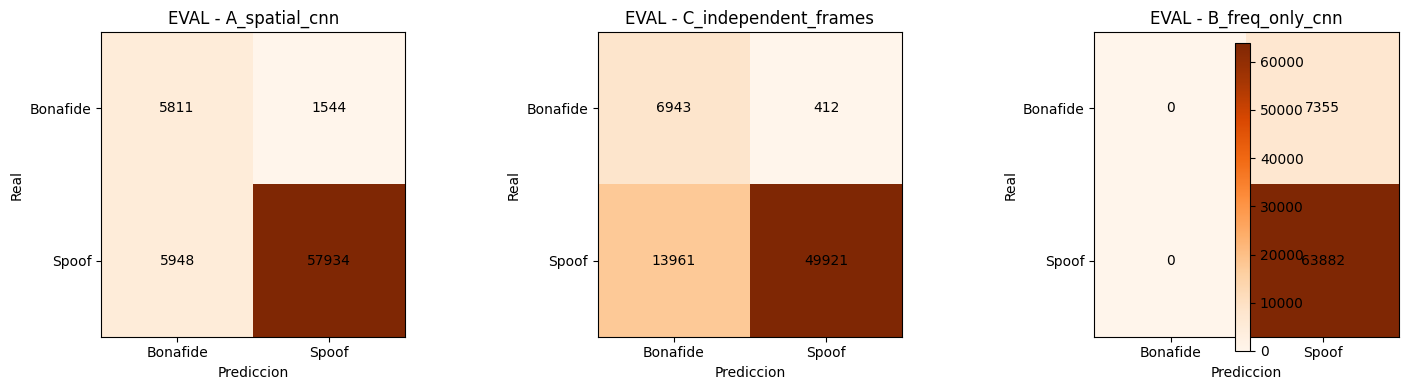

In [7]:
# ==============================
# 7) Evaluacion en conjunto EVAL (nuevos atacantes)
# ==============================
print('Shapes en EVAL:')
print('X_eval_cnn:', X_eval_cnn.shape, '| y_eval:', y_eval.shape)

# Evaluacion por modelo sobre EVAL, reutilizando umbral calibrado en DEV
all_metrics_eval = []
prob_by_model_eval = {}
cm_by_model_eval = {}
roc_data_eval = {}
pr_data_eval = {}

for name, model in models_dict.items():
    thr = thresholds_by_model[name]
    y_prob_eval = robust_predict_proba(model, X_eval_cnn)
    y_pred_eval = (y_prob_eval >= thr).astype(int)

    prob_by_model_eval[name] = y_prob_eval
    cm_by_model_eval[name] = confusion_matrix(y_eval, y_pred_eval)

    fpr_e, tpr_e, _ = roc_curve(y_eval, y_prob_eval)
    roc_data_eval[name] = (fpr_e, tpr_e)

    p_e, r_e, _ = precision_recall_curve(y_eval, y_prob_eval)
    pr_data_eval[name] = (r_e, p_e)

    m_eval = compute_metrics(y_eval, y_prob_eval, threshold=thr)
    m_eval['model'] = name
    all_metrics_eval.append(m_eval)

results_eval_df = pd.DataFrame(all_metrics_eval).set_index('model').sort_values('roc_auc', ascending=False)

cols_compare = [
    'threshold', 'accuracy', 'balanced_accuracy', 'precision_spoof', 'recall_spoof',
    'f1_spoof', 'roc_auc', 'pr_auc', 'mcc', 'kappa', 'log_loss', 'brier'
]

print('=== Resultados en EVAL (cross-domain) ===')
display(results_eval_df[cols_compare].round(4))

# Comparacion directa DEV vs EVAL
comparison = (
    results_dev_df[cols_compare].add_suffix('_dev')
    .join(results_eval_df[cols_compare].add_suffix('_eval'), how='inner')
)

for c in cols_compare:
    comparison[f'delta_{c}'] = comparison[f'{c}_eval'] - comparison[f'{c}_dev']

print('\n=== Comparacion DEV vs EVAL (delta = eval - dev) ===')
display(comparison.round(4))

# ------------------------------
# Graficos de robustez
# ------------------------------
metrics_key = ['roc_auc', 'pr_auc', 'balanced_accuracy', 'f1_spoof', 'mcc']

fig, axes = plt.subplots(1, len(metrics_key), figsize=(4 * len(metrics_key), 4))
if len(metrics_key) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics_key):
    temp = pd.DataFrame({
        'DEV': results_dev_df[metric],
        'EVAL': results_eval_df[metric],
    })
    temp.plot(kind='bar', ax=ax)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3, axis='y')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Comparacion DEV vs EVAL por metrica', y=1.03)
plt.tight_layout()
plt.show()

delta_plot = comparison[[f'delta_{m}' for m in metrics_key]].copy()
delta_plot.columns = metrics_key

ax = delta_plot.plot(kind='bar', figsize=(10, 5))
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Delta de robustez (EVAL - DEV)')
ax.set_ylabel('Cambio de metrica')
ax.set_xlabel('Modelo')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
for name, (fpr, tpr) in roc_data_eval.items():
    auc_val = results_eval_df.loc[name, 'roc_auc']
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.title('Curvas ROC en EVAL')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()

plt.figure(figsize=(7, 6))
for name, (rec, prec) in pr_data_eval.items():
    ap_val = results_eval_df.loc[name, 'pr_auc']
    plt.plot(rec, prec, label=f'{name} (AP={ap_val:.4f})')
plt.title('Curvas Precision-Recall en EVAL')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.show()

model_names_eval = list(results_eval_df.index)
fig, axes = plt.subplots(1, len(model_names_eval), figsize=(5 * len(model_names_eval), 4))
if len(model_names_eval) == 1:
    axes = [axes]

for ax, name in zip(axes, model_names_eval):
    cm = cm_by_model_eval[name]
    im = ax.imshow(cm, cmap='Oranges')
    ax.set_title(f'EVAL - {name}')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Bonafide', 'Spoof'])
    ax.set_yticklabels(['Bonafide', 'Spoof'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center')

fig.colorbar(im, ax=axes, fraction=0.025)
plt.tight_layout()
plt.show()

## Conclusiones integradas de la comparativa (3 modelos)

### 1) Resumen de resultados observados

En este experimento se compararon tres arquitecturas bajo un protocolo homogeneo (mismo `train`, misma validacion en `dev`, misma bateria de metricas y calibracion de umbral por modelo en `dev`).

Hallazgos principales:
- En **DEV (in-domain)**, el mejor rendimiento global lo obtiene **`C_independent_frames`**, con mejor equilibrio entre discriminacion (`ROC-AUC`, `PR-AUC`) y metricas de decision (`balanced_accuracy`, `MCC`).
- En **EVAL (cross-domain)**, el liderazgo pasa a **`A_spatial_cnn`**, mostrando mayor estabilidad de rendimiento ante cambio de dominio.
- **`B_freq_only_cnn`** mantiene un patron de comportamiento no deseable para despliegue: resultados aparentemente altos en algunas metricas globales, pero con degradacion estructural en la deteccion equilibrada de clases.

### 2) Hipotesis sobre la razon de los resultados

**Hipotesis H1: por que C domina en DEV.**
`C_independent_frames` trata cada frame de forma separada y agrega evidencia global al final. Esto encaja bien con una ETL basada en muestras temporales equidistantes, donde no siempre hay continuidad local fuerte entre frames. Como consecuencia, el modelo captura patrones espectrales robustos en dominio conocido.

**Hipotesis H2: por que A generaliza mejor en EVAL.**
`A_spatial_cnn` impone un sesgo inductivo mas simple y regularizado (mezcla local tiempo-frecuencia con pooling asimetrico). Ese sesgo puede sacrificar algo de rendimiento maximo en DEV, pero mejorar robustez cuando cambian los atacantes o la distribucion acustica.

**Hipotesis H3: por que B falla en equilibrio de clases.**
`B_freq_only_cnn` restringe en exceso la modelizacion temporal al no mezclar tiempo en convolucion local. En este problema, esa restriccion puede producir una frontera de decision pobremente calibrada para bonafide/spoof, especialmente bajo shift de dominio.

### 3) Lectura de negocio y operacion

Desde perspectiva de negocio antifraude, interesa minimizar tanto:
- **FN de spoof** (ataques que se escapan), como
- **FP de bonafide** (usuarios legitimos bloqueados).

Por eso se calibra el umbral en `dev` maximizando `F1` de spoof: permite equilibrar precision y recall sobre la clase de mayor riesgo economico sin contaminar `eval`.

### 4) Conclusiones finales

1. **No hay un unico ganador universal**: `C_independent_frames` optimiza rendimiento in-domain, mientras `A_spatial_cnn` ofrece mejor robustez cross-domain.
2. Si el objetivo prioritario es **generalizacion a atacantes no vistos**, la opcion mas defendible es **`A_spatial_cnn`**.
3. Si el objetivo prioritario es **maximo rendimiento en dominio conocido**, **`C_independent_frames`** sigue siendo una referencia fuerte.
4. **`B_freq_only_cnn` no se recomienda** como modelo principal en produccion sin rediseño adicional.

### 5) Limitaciones y siguientes pasos

- Repetir el experimento con varias semillas y reportar intervalos de confianza para reforzar significancia estadistica.
- Evaluar sensibilidad al criterio de umbral (por ejemplo, F1 vs coste de negocio ponderado de FP/FN).
- Validar en mas particiones o atacantes sinteticos para robustecer conclusiones de generalizacion.

Con esta evidencia, el notebook entrega una comparativa reproducible, argumentada y util para defender decisiones de arquitectura en contexto academico y aplicado.